[0]	validation_0-logloss:0.45997
[1]	validation_0-logloss:0.34184
[2]	validation_0-logloss:0.27076
[3]	validation_0-logloss:0.22399


[4]	validation_0-logloss:0.19346
[5]	validation_0-logloss:0.16814
[6]	validation_0-logloss:0.15393
[7]	validation_0-logloss:0.14081
[8]	validation_0-logloss:0.13269
[9]	validation_0-logloss:0.12515
[10]	validation_0-logloss:0.11551
[11]	validation_0-logloss:0.11184
[12]	validation_0-logloss:0.10799
[13]	validation_0-logloss:0.10541
[14]	validation_0-logloss:0.10493
[15]	validation_0-logloss:0.10326
[16]	validation_0-logloss:0.10300
[17]	validation_0-logloss:0.10339
[18]	validation_0-logloss:0.10160
[19]	validation_0-logloss:0.09892
[20]	validation_0-logloss:0.09478
[21]	validation_0-logloss:0.09359
[22]	validation_0-logloss:0.09247
[23]	validation_0-logloss:0.09284
[24]	validation_0-logloss:0.09266


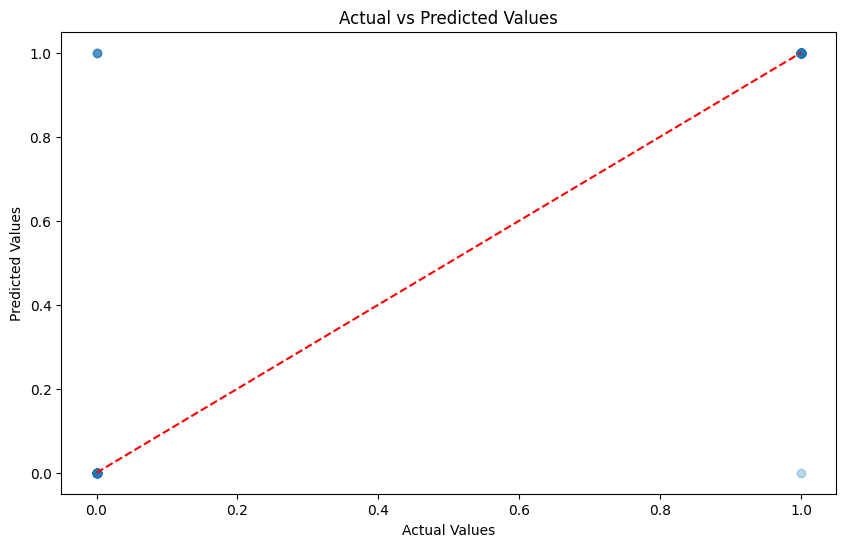

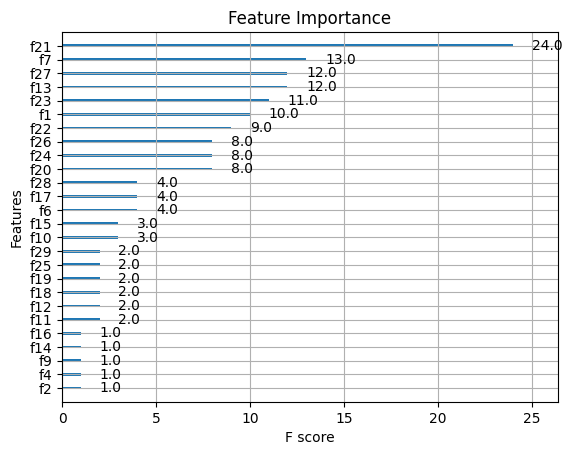

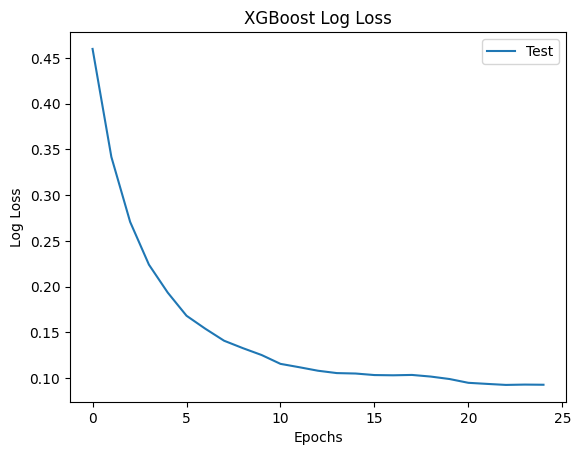

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import xgboost as xgb

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=94)

early_stop = xgb.callback.EarlyStopping(rounds=2, metric_name='logloss', data_name='validation_0', save_best=True)
clf = xgb.XGBClassifier(tree_method="hist", callbacks=[early_stop]) # with early stopping
# clf = xgb.XGBClassifier(tree_method="hist", early_stopping_rounds=2) # without early stopping

# Fit the model, test sets are used for early stopping.
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)])

# Make predictions
y_hat = clf.predict(X_test)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_hat, alpha=0.3)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

# Plot feature importance
xgb.plot_importance(clf)
plt.title('Feature Importance')
plt.show()

# Plot evaluation metric over epochs
results = clf.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['logloss'], label='Test')
ax.legend()
plt.xlabel('Epochs')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss')
plt.show()